In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import re
from bs4 import BeautifulSoup
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import spacy
from spacy import displacy
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

# For deep learning with TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [3]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
df = pd.read_csv("/content/drive/MyDrive/capstone/prime_videos.csv", encoding='ISO-8859-1')

In [5]:
df.head(3)

,rating,title_x,text,asin,parent_asin,timestamp,verified_purchase,main_category,title_y,average_rating,rating_number,description,price,categories
0,5,Five Stars,"Amazon, please buy the show! I'm hooked!",B013488XFS,B013488XFS,2015-08-24 03:07:17.000,True,Prime Video,Sneaky Pete,4.6,56658.0,['A\xa0con man (Giovanni Ribisi) on the run fr...,NaN,Suspense
1,5,Five Stars,My Kiddos LOVE this show!!,B00CB6VTDS,B00CB6VTDS,2016-04-19 21:16:50.000,True,Prime Video,Creative Galaxy,4.8,6403.0,['Follow the adventures of Arty and his sideki...,NaN,Kids
2,5,What Love Is...,"...isn't always how you expect it to be, but w...",B001H1SVZC,B001H1SVZC,2020-05-28 04:13:47.074,True,Prime Video,NaN,4.5,389.0,NaN,NaN,NaN


In [6]:
df = df[['rating', 'title_x', 'text']]
df.head()

,rating,title_x,text
0,5,Five Stars,"Amazon, please buy the show! I'm hooked!"
1,5,Five Stars,My Kiddos LOVE this show!!
2,5,What Love Is...,"...isn't always how you expect it to be, but w..."
3,5,QUIRKY TURNS TO HEARTSTRINGS,As you learn about the very unique characters ...
4,5,Way better than the harsh reviews.,Our family loved the film. We have kids and th...


In [7]:
df.isna().sum()

,0
rating,0
title_x,24
text,31


In [8]:
df.duplicated().sum()

np.int64(20573)

In [9]:
df = df.drop_duplicates()

In [10]:
df.isna().sum()

,0
rating,0
title_x,15
text,15


In [11]:
df = df.dropna()
df.shape

(213010, 3)

In [12]:
data = df.copy()

In [13]:
# Create 'sentiments' column
def classify_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'

data['sentiment'] = data['rating'].apply(classify_sentiment)

In [14]:
data['reviews'] = data['title_x'] + '  ' + data['text']

In [15]:
data = data.drop(['title_x', 'text', 'rating'], axis=1)
data.head(3)

,sentiment,reviews
0,positive,"Five Stars Amazon, please buy the show! I'm h..."
1,positive,Five Stars My Kiddos LOVE this show!!
2,positive,What Love Is... ...isn't always how you expec...


In [16]:
data['sentiment'].value_counts()

,count
sentiment,
positive,158550
negative,32559
neutral,21901


In [17]:
def strip_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    stripped_text = soup.get_text()
    return stripped_text

In [18]:
data['reviews'] = data['reviews'].apply(strip_html_tags)
data['reviews'][:3]

,reviews
0,"Five Stars Amazon, please buy the show! I'm h..."
1,Five Stars My Kiddos LOVE this show!!
2,What Love Is... ...isn't always how you expec...


In [19]:
# Define a function for text preprocessing
def preprocess_text(text):
    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and symbols
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Lemmatize text
    lemmatizer = WordNetLemmatizer()
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

    # Remove stop words
    stop_words = set(stopwords.words('english'))

    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

In [20]:
# Apply the preprocessing function to the 'reviews'
data["clean_review"] = data["reviews"].apply(preprocess_text)

In [21]:
# verify the changes
data['clean_review'].head()

,clean_review
0,five star amazon please buy show im hooked
1,five star kiddos love show
2,love isnt always expect know movie deep strugg...
3,quirky turn heartstrings learn unique characte...
4,way better harsh review family loved film kid ...


In [22]:
data = data.reset_index(drop=True)

- Create a corpus list which will contain all the articles.

In [23]:
# Create an empty corpus list
articles = []

# Append each text entry from the 'clean_review' column to the corpus using a loop.
for entry in data['clean_review']:
    articles.append(entry)

In [24]:
articles[1]

'five star kiddos love show'

- Create a vocabulary size which is the total number of unique words that the model will recognize and process.

In [25]:
### Vocabulary size
voc_size=5000

In [26]:
#onehot_repr
onehot_repr=[one_hot(str(words),voc_size)for words in articles]

In [27]:
len(onehot_repr[1])

5

### Embedding Representation

- Create a sentence length of 50 which defines the maximum length of a sequence for each document in the dataset. Neural networks expect input data to have a consistent shape. Since each document may have different number of words, you must pad or truncate the sequences to ensure they all have the same length.

- We then use pad_sequences to standardize the length of sequences by adding padding to them (if they are too short) or truncating them (if they are too long).

In [28]:
sent_length=30
embedded_docs=pad_sequences(onehot_repr,padding='post',maxlen=sent_length)
print(embedded_docs)

[[ 402 1187 4600 ...    0    0    0]
 [ 402 1187 2511 ...    0    0    0]
 [1036  685 1341 ... 1910 4515 3831]
 ...
 [2617 2130  681 ... 2102 2130 4314]
 [3920 3932 2587 ...  391 3771 1341]
 [ 761 3710  635 ... 2102 3710  223]]


In [29]:
embedded_docs[1]

array([ 402, 1187, 2511,  391, 3043,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0], dtype=int32)

## LSTM model

In [30]:
## Creating model
# Define the number of dimensions for the embedding vectors.
# This is the size of the vector that will represent each word.
embedding_vector_features= 40

# Initialize a Sequential model
model=Sequential()

# Add an Embedding layer.
model.add(Embedding(input_dim= voc_size,
                    output_dim= embedding_vector_features,
                    input_length=sent_length))

# Add an LSTM layer with 100 units.
# LSTM (Long Short-Term Memory) helps capture temporal dependencies in sequential data.
model.add(LSTM(100))
model.add(Dropout(0.3))

# Add a Dense layer with a single neuron.
# The 'sigmoid' activation function is used for binary classification.
model.add(Dense(3, activation='softmax'))

# Compile the model.
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model.build(input_shape=(None, sent_length))
# Print the model summary to see the architecture and number of parameters.
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 30, 40)              │         200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          56,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 256,703 (1002.75 KB)

 Trainable params: 256,703 (1002.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [31]:
len(embedded_docs)

213010

In [32]:
y_final=data['sentiment']
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
y_final = y_final.map(sentiment_mapping)
y_final[:5]

,sentiment
0,2
1,2
2,2
3,2
4,2


In [33]:
X_final=np.array(embedded_docs)
y_final=np.array(y_final)

In [34]:
y_final

array([2, 2, 2, ..., 2, 2, 2])

In [35]:
X_final.shape,y_final.shape

((213010, 30), (213010,))

- Perform train test split using a random state of 42 and a test size of 30%

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=42)

In [37]:
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

In [38]:
### Training
model.fit(X_train,y_train,
          validation_data=(X_test,y_test),
          epochs=10,
          batch_size=32)

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.8112 - loss: 0.5137 - val_accuracy: 0.8559 - val_loss: 0.4084
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.8628 - loss: 0.3669 - val_accuracy: 0.8616 - val_loss: 0.3697
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.8739 - loss: 0.3338 - val_accuracy: 0.8638 - val_loss: 0.3651
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8833 - loss: 0.3102 - val_accuracy: 0.8611 - val_loss: 0.3712
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - accuracy: 0.8925 - loss: 0.2871 - val_accuracy: 0.8541 - val_loss: 0.3909
Epoch 6/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.9009 - loss: 0.2652 - val_accuracy: 0.8563 - val_loss: 0.4021
Epoch 7/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9075 - loss: 0.2463 - val_accuracy: 0.8519 - val_loss: 0.4391
Epoch 8/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.9181 - loss: 0

In [39]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 0.5644938945770264
Test Accuracy: 0.8363926410675049


## Bidirectional LSTM model

In [40]:
## Creating bidirectional model
embedding_vector_features=40
model2=Sequential()

model2.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))

model2.add(Bidirectional(LSTM(100)))
model.add(Dropout(0.3))

model2.add(Dense(3,activation='softmax'))

model2.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

model2.build(input_shape=(None, sent_length))
print(model2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 30, 40)              │         200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 200)                 │         112,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             603 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 313,403 (1.20 MB)

 Trainable params: 313,403 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss',  # Monitor validation loss
                               patience=3,  # Stop training if no improvement for 3 epochs
                               restore_best_weights=True,  # Restore best model weights
                               verbose=1)

In [42]:
## Model Training
history = model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=32,
                     callbacks=[early_stopping])

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.8296 - loss: 0.4571 - val_accuracy: 0.8615 - val_loss: 0.3658
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.8688 - loss: 0.3443 - val_accuracy: 0.8635 - val_loss: 0.3579
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.8805 - loss: 0.3117 - val_accuracy: 0.8635 - val_loss: 0.3629
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - accuracy: 0.8941 - loss: 0.2787 - val_accuracy: 0.8620 - val_loss: 0.3877
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.9064 - loss: 0.2505 - val_accuracy: 0.8559 - val_loss: 0.3988
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [43]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Loss: [0.40299132466316223, 0.34768593311309814, 0.3179270625114441, 0.28852856159210205, 0.25918927788734436]
Validation Loss: [0.36581218242645264, 0.3578816056251526, 0.3629441559314728, 0.3877260684967041, 0.3987659513950348]
Train Accuracy: [0.8491485714912415, 0.8671960234642029, 0.8781210780143738, 0.8904947638511658, 0.902647078037262]
Validation Accuracy: [0.861461877822876, 0.8634962439537048, 0.8634962439537048, 0.862009584903717, 0.8558753132820129]


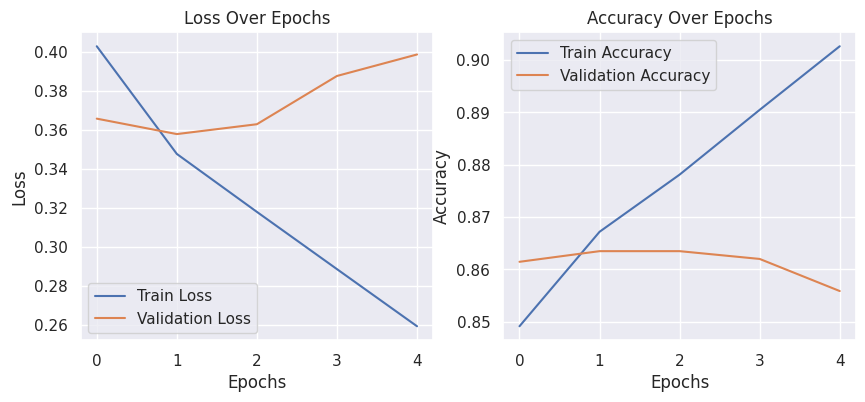

In [44]:
# **Plot Loss**
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# **Plot Accuracy**
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

### Create a function to build and train a bi-lstm model

In [45]:
def build_and_train_bilstm(voc_size, sent_length, X_train, y_train, X_test, y_test,
                           embedding_dim=40, lstm_units=100, dropout_rate=0.3, optimizer='adam',
                           epochs=10, batch_size=32, patience=3):
    """
    Function to build, train, and evaluate a BiLSTM model with early stopping.

    Parameters:
    - voc_size: Vocabulary size
    - sent_length: Maximum sentence length
    - X_train, y_train: Training data and labels
    - X_test, y_test: Test data and labels
    - embedding_dim: Dimension of word embeddings
    - lstm_units: Number of LSTM units
    - dropout_rate: Dropout rate to prevent overfitting
    - optimizer: Optimizer to use ('adam' or 'rmsprop')
    - epochs: Number of training epochs
    - batch_size: Batch size for training
    - patience: Early stopping patience

    Returns:
    - Trained model
    - Training history
    """

    # Build the model
    model = Sequential()
    model.add(Embedding(input_dim=voc_size, output_dim=embedding_dim, input_length=sent_length))
    model.add(Bidirectional(LSTM(lstm_units, return_sequences=False)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(3, activation='softmax'))  # Assuming 3 sentiment classes

    # Compile model
    optimizer = Adam() if optimizer == 'adam' else RMSprop()
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1)

    # Train model
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, callbacks=[early_stopping])

    # Evaluate model
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    return model, history

Epoch 1/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8217 - loss: 0.4782 - val_accuracy: 0.8571 - val_loss: 0.3780
Epoch 2/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8669 - loss: 0.3523 - val_accuracy: 0.8633 - val_loss: 0.3578
Epoch 3/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8795 - loss: 0.3169 - val_accuracy: 0.8620 - val_loss: 0.3657
Epoch 4/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8887 - loss: 0.2930 - val_accuracy: 0.8571 - val_loss: 0.3778
Epoch 5/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9003 - loss: 0.2673 - val_accuracy: 0.8553 - val_loss: 0.3962
Epoch 6/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9107 - loss: 0.2405 - val_accuracy: 0.8535 - val_loss: 0.4264
Epoch 7/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9202 - loss: 0.2157 - val_accuracy: 0.8442 - val_loss: 0.4784
Epoch 7: early stopping
Restoring model weights from the end of the best epo

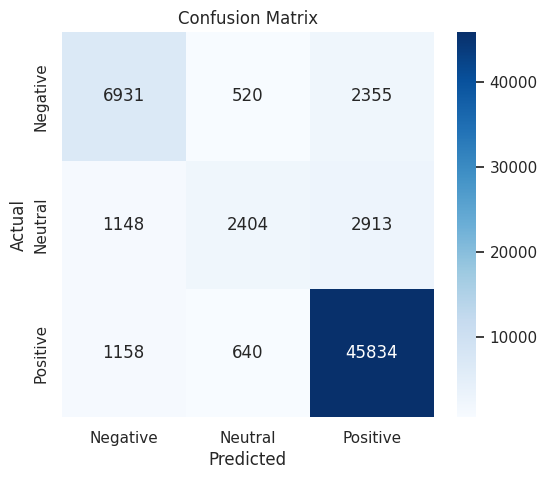


Classification Report:
               precision    recall  f1-score   support

    Negative       0.75      0.71      0.73      9806
     Neutral       0.67      0.37      0.48      6465
    Positive       0.90      0.96      0.93     47632

    accuracy                           0.86     63903
   macro avg       0.77      0.68      0.71     63903
weighted avg       0.85      0.86      0.85     63903



(<Sequential name=sequential_2, built=True>,
 <keras.src.callbacks.history.History at 0x7d36ac0d5390>)

In [46]:
build_and_train_bilstm(
    voc_size=5000,
    sent_length=100,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    embedding_dim=50,
    lstm_units=128,
    dropout_rate=0.4,
    # optimizer='rmsprop',
    epochs=10,
    batch_size=64,
    patience=5
)

Epoch 1/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.8308 - loss: 0.4543 - val_accuracy: 0.8622 - val_loss: 0.3640
Epoch 2/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - accuracy: 0.8677 - loss: 0.3467 - val_accuracy: 0.8640 - val_loss: 0.3578
Epoch 3/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - accuracy: 0.8796 - loss: 0.3149 - val_accuracy: 0.8636 - val_loss: 0.3635
Epoch 4/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.8901 - loss: 0.2885 - val_accuracy: 0.8575 - val_loss: 0.3831
Epoch 5/10
4660/4660 ━━━━━━━━━━━━━━━━━━━━ 84s 11ms/step - accuracy: 0.9033 - loss: 0.2561 - val_accuracy: 0.8590 - val_loss: 0.4005
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


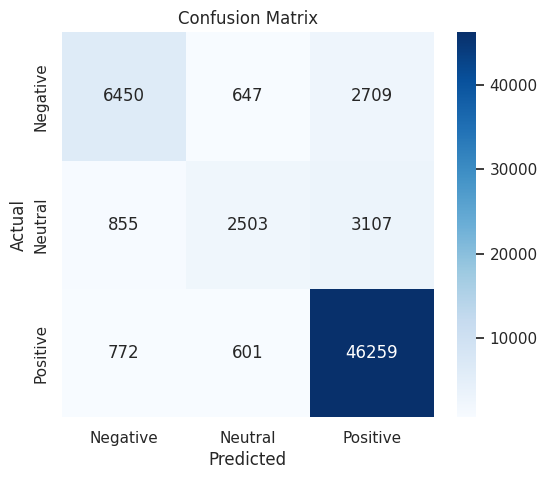


Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.66      0.72      9806
     Neutral       0.67      0.39      0.49      6465
    Positive       0.89      0.97      0.93     47632

    accuracy                           0.86     63903
   macro avg       0.78      0.67      0.71     63903
weighted avg       0.85      0.86      0.85     63903



(<Sequential name=sequential_3, built=True>,
 <keras.src.callbacks.history.History at 0x7d36a7bf2a50>)

In [47]:
build_and_train_bilstm(
    voc_size=5000,
    sent_length=50,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    embedding_dim=50,
    lstm_units=256,
    dropout_rate=0.3,
    optimizer='adam',
    epochs=10,
    batch_size=32,
    patience=3
)

Epoch 1/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8224 - loss: 0.4748 - val_accuracy: 0.8597 - val_loss: 0.3682
Epoch 2/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8666 - loss: 0.3554 - val_accuracy: 0.8636 - val_loss: 0.3585
Epoch 3/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8764 - loss: 0.3253 - val_accuracy: 0.8633 - val_loss: 0.3595
Epoch 4/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8872 - loss: 0.2959 - val_accuracy: 0.8623 - val_loss: 0.3718
Epoch 5/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8979 - loss: 0.2719 - val_accuracy: 0.8588 - val_loss: 0.3882
Epoch 6/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.9087 - loss: 0.2459 - val_accuracy: 0.8538 - val_loss: 0.4226
Epoch 7/10
2330/2330 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9202 - loss: 0.2184 - val_accuracy: 0.8481 - val_loss: 0.4607
Epoch 7: early stopping
Restoring model weights from the end of the best epo

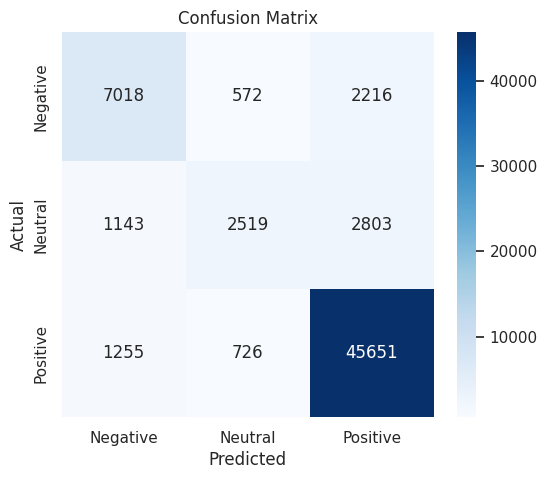


Classification Report:
               precision    recall  f1-score   support

    Negative       0.75      0.72      0.73      9806
     Neutral       0.66      0.39      0.49      6465
    Positive       0.90      0.96      0.93     47632

    accuracy                           0.86     63903
   macro avg       0.77      0.69      0.72     63903
weighted avg       0.85      0.86      0.85     63903



In [50]:
# Train and tune the BiLSTM model
model, history = build_and_train_bilstm(
    voc_size=5000,
    sent_length=100,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    embedding_dim=50,
    lstm_units=128,
    dropout_rate=0.4,
    # optimizer='rmsprop',
    epochs=10,
    batch_size=64,
    patience=5
)

## Class-wise Analysis
### 1. Negative Sentiment

- Precision = 0.75 → 75% of the reviews classified as "Negative" were actually negative.

- Recall = 0.72 → 72% of actual negative reviews were correctly identified.

- F1-Score = 0.73 → A good balance between precision and recall.

- What it means: The model does a decent job at detecting negative reviews, but it still misclassifies around 28% of them.

### 2. Neutral Sentiment

- Precision = 0.66 → 66% of reviews predicted as "Neutral" were actually neutral.

- Recall = 0.39 → Only 39% of actual neutral reviews were correctly classified.

- F1-Score = 0.49 → The model struggles with neutral reviews.

- What it means: The neutral class is the weakest—it has the lowest recall (39%), meaning the model fails to recognize a lot of neutral reviews. Many neutral reviews might be misclassified as either negative or positive.

### 3. Positive Sentiment

- Precision = 0.90 → 90% of reviews predicted as "Positive" were actually positive.

- Recall = 0.96 → 96% of actual positive reviews were correctly classified.

- F1-Score = 0.93 → The highest performance among all classes.

- What it means: The model is very good at identifying positive reviews. The high recall (96%) means it captures almost all positive reviews correctly.

## Overall Model Performance

- Accuracy = 86% → The model correctly classified 86% of all reviews.

- Macro Avg (F1-score = 0.72) → The average performance across all three classes. The neutral class is dragging the score down.

- Weighted Avg (F1-score = 0.85) → Since positive reviews dominate the dataset, the overall model performance is skewed toward positive predictions.

## Key Takeaways & Issues

1. The model performs well on positive reviews but struggles with neutral ones.

- High recall for positive (96%)

- Low recall for neutral (39%)

2. Possible Reasons for Poor Neutral Performance:

- Imbalance in the dataset

- Feature overlap → Neutral reviews might share words with both negative and positive classes, making classification harder.

- Model bias → The model might lean towards classifying neutral reviews as positive.

## Next Steps to Improve Performance

- Data augmentation: Augment neutral reviews to increase representation.

- Use BERT instead of BiLSTM: Since BiLSTM struggles with ambiguous language, fine-tuning BERT might improve neutral classification.

In [52]:
# Save the model after tuning
model.save("/content/drive/MyDrive/capstone/bilstm_sentiment_final.h5")
print("\n✅ Final tuned model saved as 'bilstm_sentiment_final.h5'")


✅ Final tuned model saved as 'bilstm_sentiment_final.h5'
